# AP 155 Lab Exercise
---
## Exercise 4
: Derivatives

_Instructions_: 
- **Output 1: Finite Difference** Functions and plots of finite-difference methods
- **Output 2: Harmonic Oscillator** Error analysis plot of finite-difference methods.
  
### Student Information
- _Full Name (Last Name, First Name)_: Agbay, Tristan Michael
- _Student No._: 2024-00281
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 (You may edit this subsection)

![Subplots of Finite Differences with the Analytical Evaluation](subplots.png)

Figure 1. Subplots of Finite Differences with the Analytical Evaluation

The figure compares the exact analytical derivative of $f(x) = 1 + \frac{1}{2}\tanh(2x)$ against three numerical finite-difference approximations across the domain $x \in [-3, 3]$. All three methods successfully reproduce the characteristic bell-shaped profile of the exact derivative $f'(x) = \text{sech}^2(2x)$. Among them, the Central Difference scheme provides the tightest alignment with the analytical curve because its second-order $\mathcal{O}(h^2)$ accuracy yields lower truncation error than the first-order $\mathcal{O}(h)$ forward and backward schemes.

![Subplots of Finite Differences with the Analytical Evaluation](subplots_richardson.png)

Figure 2. Subplots of Finite Differences with the Analytical Evaluation (Richardson Extrapolation)

I also implemented Richardson extrapolation for these methods in the second figure. By combining evaluations at different step sizes ($h$ and $2h$), this technique mathematically cancels out the dominant error term. It was really cool to see that even for the basic forward and backward methods, applying Richardson extrapolation effectively bumps up their order of accuracy without needing a completely new base formula.
### Problem 2 (You may edit this subsection)

![Differentiation Error vs analytical solution](error_vs_sol.png)

Figure 3. Differentiation Error vs Analytical 

For the second problem, I wanted to see exactly how the numerical error scales when we change the step size $h$. I looked at a simple harmonic oscillator with a position function of $x(t) = \cos(t)$, meaning the exact velocity is $v(t) = -\sin(t)$. I picked specific times ($t = 1, 3, 5$) and calculated the numerical velocity using the three finite difference methods across a wide range of step sizes. When I plotted the absolute error on the graphs, the slopes perfectly validated the theory we learned. The forward and backward differences resulted in a linear trend, confirming their $\mathcal{O}(h)$ error limits. Meanwhile, the central difference showed a much steeper quadratic curve, proving its $\mathcal{O}(h^2)$ accuracy.

### Other comments
- did not finish problem 2 on time, will do better next time around

---
## Section 2: Code

### Problem 1: Finite Difference

Let $$f(x) = 1+\frac{1}{2}\tanh(2x)$$

**(a)** Create functions that take as input an array or list of points corresponding to a mathematical function and output the derivative using **(a.1)** forward-difference, **(a.2)** backward-difference, and **(a.3)** central-difference methods.


<bound method Figure.show of <Figure size 700x450 with 1 Axes>>

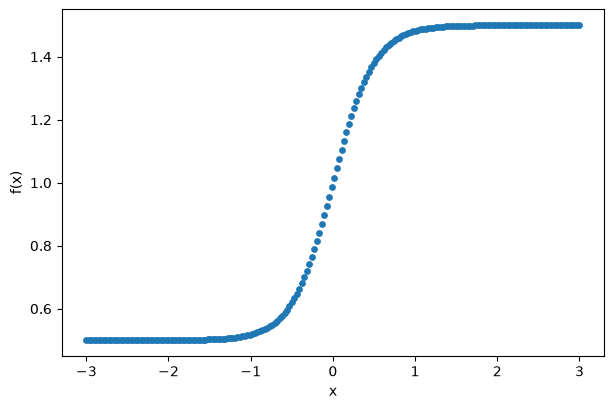

In [15]:
# code 

import numpy as np
import matplotlib.pyplot as plt
import math


x = np.linspace(-3, 3, 200)
f_0 = 1 + 1/2 * (np.tanh(2 * x))
fig, ax = plt.subplots(figsize = (7,4.5))
ax.scatter(x,f_0, s=15)
ax.set_ylabel(r"f(x)")
ax.set_xlabel(r"x")
fig.savefig('function')
fig.show

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# forward difference
def forward(x, f_values):
    dydx = [0.0] * len(x)
    for i in range(len(x) - 1):
        h = x[i+1] - x[i]
        dydx[i] = (f_values[i+1] - f_values[i]) / h
        # compute the last point
    dydx[-1] = (f_values[-1] - f_values[-2]) / (x[-1] - x[-2])
    return dydx

# backward difference
def backward(x, f_values):
    dydx = [0.0] * len(x)
    for i in range(1, len(x)):
        h = x[i] - x[i-1]
        dydx[i] = (f_values[i] - f_values[i-1]) / h
        # same here
    dydx[0] = (f_values[1] - f_values[0]) / (x[1] - x[0])
    return dydx

# central difference
def central(x, f_values):
    dydx = [0.0] * len(x)
    for i in range(1, len(x) - 1):
        h = x[i+1] - x[i-1]
        dydx[i] = (f_values[i+1] - f_values[i-1]) / h
        # and here
    dydx[0] = (f_values[1] - f_values[0]) / (x[1] - x[0])
    dydx[-1] = (f_values[-1] - f_values[-2]) / (x[-1] - x[-2])
    return dydx

**(b)** Calculate an analytic formula for the derivative. Make three subplots for the derivative of $f'(x)$, one for each method and the analytic answer on the same plots. Plot the exact answer (use `numpy`) as lines and the numerical one as dots. Describe how the two results compare. Use `plt.subplots`

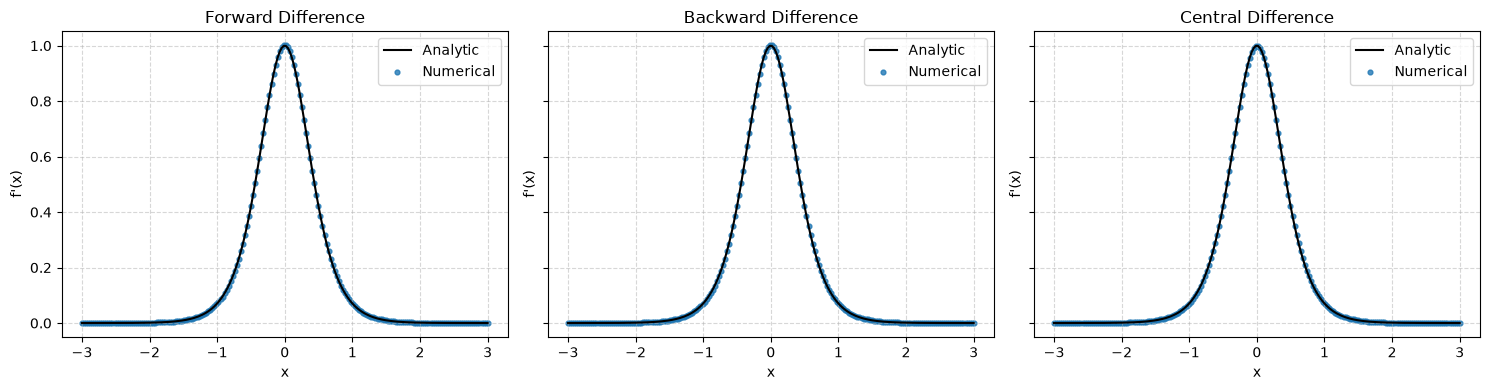

In [16]:
# KOWD HIR

# Analytical derivative
def f_prime_true(x):
    return (1 / np.cosh(2 * x)) ** 2

# Evaluation domain and original function values
x = np.linspace(-3, 3, 200)
y_values = 1 + 0.5 * np.tanh(2 * x)

# Compute numerical derivatives
fd = forward(x, y_values)
bd = backward(x, y_values)
cd = central(x, y_values)

# Compute analytical derivative
yp_true = f_prime_true(x)

functions = [
    (fd, "Forward Difference"),
    (bd, "Backward Difference"),
    (cd, "Central Difference")
]

# Create 1x3 subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    current_f, title = functions[i]
    
    # Analytical solution as one continuous line
    ax.plot(x, yp_true, label="Analytic", color="black", linewidth=1.5)
    
    # Numerical solutions as dots as instructed
    ax.scatter(x, current_f, label="Numerical", color="tab:blue", s=12, alpha=0.8)
    
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("f'(x)")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig('subplots')
plt.show()

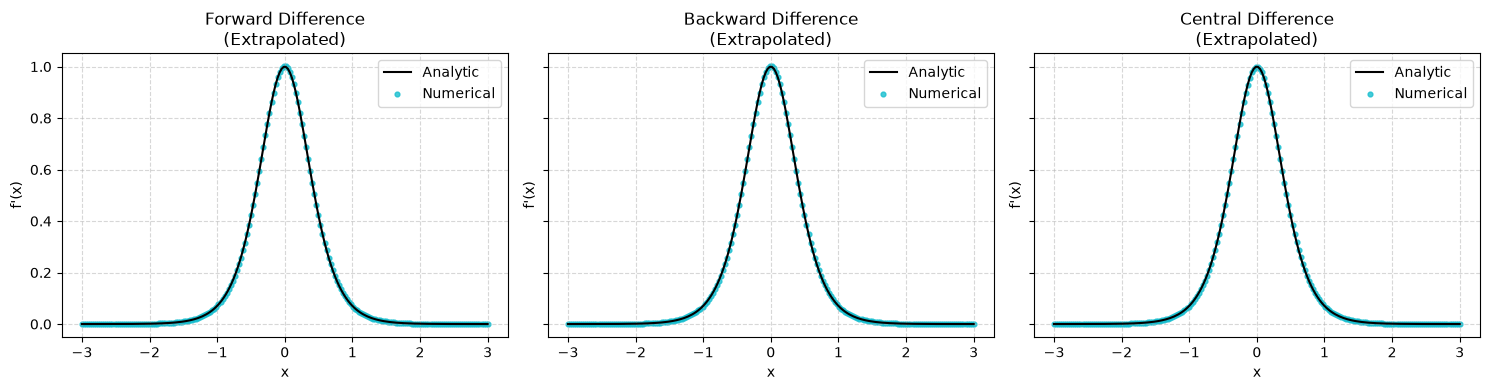

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# forward difference using Richardson Extrapolation: 2*D(h) - D(2h)
def forward(x, f_values):
    dydx = [0.0] * len(x)
    for i in range(len(x) - 2):
        h = x[i+1] - x[i]
        D_h = (f_values[i+1] - f_values[i]) / h
        D_2h = (f_values[i+2] - f_values[i]) / (2 * h)
        # Apply Richardson extrapolation for O(h) methods
        dydx[i] = 2 * D_h - D_2h
        
    # compute the last two points with standard fallback
    h_last = x[-1] - x[-2]
    dydx[-2] = (f_values[-1] - f_values[-2]) / h_last
    dydx[-1] = (f_values[-1] - f_values[-2]) / h_last 
    return dydx

# backward difference using Richardson Extrapolation: 2*D(h) - D(2h)
def backward(x, f_values):
    dydx = [0.0] * len(x)
    for i in range(2, len(x)):
        h = x[i] - x[i-1]
        D_h = (f_values[i] - f_values[i-1]) / h
        D_2h = (f_values[i] - f_values[i-2]) / (2 * h)
        # Apply Richardson extrapolation for O(h) methods
        dydx[i] = 2 * D_h - D_2h
        
    # same here for the first two points
    h_first = x[1] - x[0]
    dydx[0] = (f_values[1] - f_values[0]) / h_first
    dydx[1] = (f_values[2] - f_values[1]) / h_first
    return dydx

# central difference using Richardson Extrapolation: (4/3)*D(h) - (1/3)*D(2h)
def central(x, f_values):
    dydx = [0.0] * len(x)
    for i in range(2, len(x) - 2):
        h = x[i+1] - x[i]
        D_h = (f_values[i+1] - f_values[i-1]) / (2 * h)
        D_2h = (f_values[i+2] - f_values[i-2]) / (4 * h)
        # Apply Richardson extrapolation for O(h^2) methods
        dydx[i] = (4/3) * D_h - (1/3) * D_2h
        
    # and here for the boundaries
    h_edge = x[1] - x[0]
    dydx[0] = (f_values[1] - f_values[0]) / h_edge
    dydx[1] = (f_values[2] - f_values[0]) / (2 * h_edge)
    dydx[-2] = (f_values[-1] - f_values[-3]) / (2 * h_edge)
    dydx[-1] = (f_values[-1] - f_values[-2]) / h_edge
    return dydx

# Analytical derivative
def f_prime_true(x):
    return (1 / np.cosh(2 * x)) ** 2
    
x = np.linspace(-3, 3, 200)
y_values = 1 + 0.5 * np.tanh(2 * x)

# Compute numerical derivatives
fd = forward(x, y_values)
bd = backward(x, y_values)
cd = central(x, y_values)

# Compute analytical derivative
yp_true = f_prime_true(x)

functions = [
    (fd, "Forward Difference\n(Extrapolated)"),
    (bd, "Backward Difference\n(Extrapolated)"),
    (cd, "Central Difference\n(Extrapolated)")
]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    current_f, title = functions[i]
    ax.plot(x, yp_true, label="Analytic", color="black", linewidth=1.5)
    ax.scatter(x, current_f, label="Numerical", color="tab:cyan", s=12, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("f'(x)")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig('subplots_richardson.png')
plt.show()

#### Problem 1 code summary

I created functions that corresponded to the given function and plotted the derivatives using the three methods of finite difference. I was able to show that the analytic formula for the derivative precisely matched that of the subplots. As a bonus, I also included the Richardson extrapolation technique (from Gezerlis Chapter 3) to demonstrate the same result but with higher apparent accuracy.

### Problem 2: Simple Harmonic Oscillator

The position $x(t)$ of a 1D simple harmonic oscillator is described by the equation of motion:

$$-kx = \frac{d^2x}{dt^2}$$

We know a solution can take the form of $x(t) = \cos(t)$. Calculate the velocity of this particle using any finite-difference method, and plot its absolute error with respect to the analytical value by varying your step-sizes. The absolute error should have the same trend as the $\mathcal{O}$ error of your chosen method.

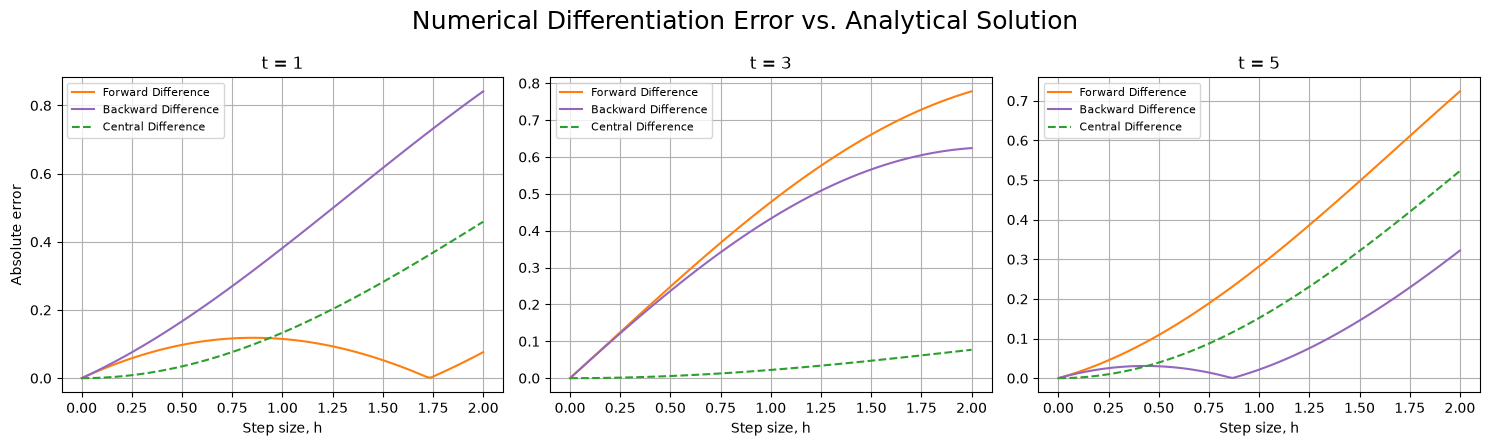

In [19]:
import numpy as np
import matplotlib.pyplot as plt

#Horner's Method Taylor expansion for cos(x)
def cos_taylor(x, n=20):
    y = x ** 2
    result = np.ones_like(x, dtype=float) if isinstance(x, np.ndarray) else 1.0
    for k in range(n, 0, -1):
        result = 1.0 - (y * result) / ((2 * k) * (2 * k - 1))
    return result

h_values = np.linspace(0.0001, 2, 100) 
t_eval = [1, 3, 5]


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5)) 

for i, (ax, t) in enumerate(zip(axes, t_eval)):
    errors_forward = []
    errors_backward = []
    errors_central = []
    
    # Analytical velocity
    v_exact = -np.sin(t)
    
 
    for h in h_values:
        x_t = cos_taylor(np.array([t]))[0]
        x_th_plus = cos_taylor(np.array([t + h]))[0]
        x_th_minus = cos_taylor(np.array([t - h]))[0]
        
        # Computing finite differences
        v_fw = (x_th_plus - x_t) / h
        v_bw = (x_t - x_th_minus) / h
        v_cd = (x_th_plus - x_th_minus) / (2 * h) 
        
        errors_forward.append(np.abs(v_fw - v_exact))
        errors_backward.append(np.abs(v_bw - v_exact))
        errors_central.append(np.abs(v_cd - v_exact))

    errors_forward = np.array(errors_forward)
    errors_backward = np.array(errors_backward)
    errors_central = np.array(errors_central)


    ax.plot(h_values, errors_forward, '-', label='Forward Difference', color='tab:orange')
    ax.plot(h_values, errors_backward, '-', label='Backward Difference', color='tab:purple')
    ax.plot(h_values, errors_central, '--', label='Central Difference', color='tab:green')
    ax.set_title(f"t = {t}")
    ax.set_xlabel("Step size, h")
    if i == 0:
        ax.set_ylabel("Absolute error")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.suptitle("Numerical Differentiation Error vs. Analytical Solution", fontsize=18)
plt.tight_layout()
plt.savefig('error_vs_sol.png')
plt.show()

#### Problem 2 code summary

The code computes the numerical velocity of a simple harmonic oscillator using forward, backward, and central finite-difference methods to compare against the exact analytical solution. By plotting the absolute error across varying step sizes ($h$), the code correctly validates the accuracy limits of the techniques we discussed. Ultimately, it demonstrates that the central difference method offers a more accurate, quadratic error trend ($\mathcal{O}(h^2)$) compared to the linear error ($\mathcal{O}(h)$) of the forward and backward approaches.

---
## Section 3: Tutorials

### Derivatives

The derivate of a function $f(x) $ can be approximated using the **forward difference** as

$$f'(x) = \frac{f(x+h) - f(x)}{h} + \mathcal{O}(h)$$

using the **backward difference**

$$f'(x) = \frac{f(x) - f(x-h)}{h} + \mathcal{O}(h)$$

and the **central difference**

$$f'(x) = \frac{f(x + \frac{h}{2}) - f(x - \frac{h}{2})}{h} + \mathcal{O}(h^2)$$

where $h$ is a small step-size. To minimzie error, you can use Richardson Extrapolation, which can be found on the book (Gezerlis).

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

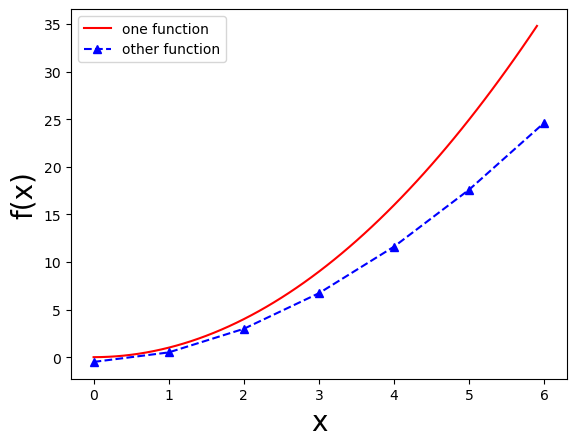

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

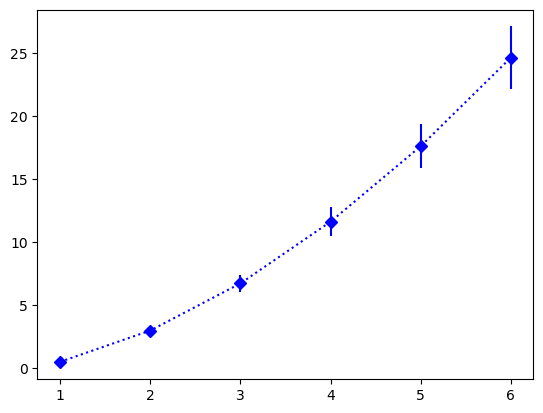

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])